# Shapash in Jupyter - Debugging a Titanic Model with Explainability

In this tutorial, we use explainability to detect a classic ML issue: target leakage.

You will:
- build a deliberately flawed model
- identify the bug using Shapash plots
- fix the pipeline and compare performance
- leave with a functional and numerical validation checklist

In [ ]:
import pandas as pd

from category_encoders import one_hot
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading

## 1. Load Titanic data

In [2]:
titanic_df, _ = data_loading("titanic")

# Same mapping logic as shapash/webapp/webapp_launch.py
titanic_df["Pclass"] = titanic_df["Pclass"].map({"First class": 1, "Second class": 2, "Third class": 3})

# Some dataset versions do not include Title: rebuild it if needed.
if "Title" not in titanic_df.columns:
    titanic_df["Title"] = titanic_df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).fillna("Unknown")

target_name = "Survived"
titanic_df[["Pclass", "Age", "Sex", "SibSp", "Parch", "Fare", "Embarked", "Title", target_name]].head()

,Pclass,Age,Sex,SibSp,Parch,Fare,Embarked,Title,Survived
PassengerId,,,,,,,,,
1,3,22.0,male,1,0,7.25,Southampton,Mr,0
2,1,38.0,female,1,0,71.28,Cherbourg,Mrs,1
3,3,26.0,female,0,0,7.92,Southampton,Miss,1
4,1,35.0,female,1,0,53.10,Southampton,Mrs,1
5,3,35.0,male,0,0,8.05,Southampton,Mr,0


## 2. Common ML mistakes to keep in mind

These are exactly the kinds of mistakes explainability can uncover:
- target leakage: a feature computed using the target (directly or indirectly)
- business variables that are unavailable at prediction time
- confusion between missing values and actual numeric values
- unstable encoding between training and inference
- metrics that are not suitable for imbalanced classes
- feature engineering that depends on future information (time leakage)

## 3. Build a deliberately flawed model (with target leakage)

We create a `leak_survival_rate_by_title` variable using the true `Survived` target over the full dataset.
This is a practical way to show how a suspicious feature immediately stands out in Shapash.

In [ ]:
df_bug = titanic_df.copy()

# Intentional bug: target leakage (mean Survived computed on all rows)
df_bug["leak_survival_rate_by_title"] = df_bug.groupby("Title")[target_name].transform("mean")

features_bug = [
    "Pclass", "Age", "Sex", "SibSp", "Parch", "Fare", "Embarked", "Title",
    "leak_survival_rate_by_title",
]

X_bug_raw = df_bug[features_bug]
y = df_bug[[target_name]]

X_bug_train_raw, X_bug_test_raw, y_bug_train, y_bug_test = train_test_split(
    X_bug_raw,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

encoder_bug = one_hot.OneHotEncoder(cols=["Sex", "Embarked", "Title"])
X_bug_train = encoder_bug.fit_transform(X_bug_train_raw)
X_bug_test = encoder_bug.transform(X_bug_test_raw)

model_bug = LGBMClassifier(max_depth=4, n_estimators=200, learning_rate=0.05, verbose=-1)
model_bug.fit(X_bug_train, y_bug_train.iloc[:, 0])

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [4]:
def cls_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

y_bug_pred_train = model_bug.predict(X_bug_train)
y_bug_pred_test = model_bug.predict(X_bug_test)

metrics_bug = pd.DataFrame(
    [
        cls_metrics(y_bug_train.iloc[:, 0], y_bug_pred_train),
        cls_metrics(y_bug_test.iloc[:, 0], y_bug_pred_test),
    ],
    index=["train_bug", "test_bug"],
)
metrics_bug

,accuracy,precision,recall,f1
train_bug,0.913174,0.930435,0.835938,0.880658
test_bug,0.802691,0.791667,0.662791,0.721519


## 4. Explain the flawed model with Shapash

In [5]:
feature_dict_bug = {
    "Pclass": "Ticket class",
    "Age": "Age",
    "Sex": "Sex",
    "SibSp": "Number of siblings/spouses",
    "Parch": "Number of parents/children",
    "Fare": "Ticket fare",
    "Embarked": "Port of embarkation",
    "Title": "Title",
    "leak_survival_rate_by_title": "SURVIVAL RATE BY TITLE (LEAK)",
}

postprocess = {
    "Age": {"type": "suffix", "rule": " years"},
    "Sex": {"type": "transcoding", "rule": {"male": "Man", "female": "Woman"}},
    "Pclass": {"type": "transcoding", "rule": {1: "First", 2: "Second", 3: "Third"}},
}

xpl_bug = SmartExplainer(
    model=model_bug,
    preprocessing=encoder_bug,
    features_dict=feature_dict_bug,
    label_dict={0: "Deceased", 1: "Survived"},
    postprocessing=postprocess,
    title_story="Titanic model debugging - buggy version",
)

y_bug_pred_test_df = pd.DataFrame(
    model_bug.predict(X_bug_test),
    columns=[target_name],
    index=X_bug_test.index,
)

xpl_bug.compile(
    x=X_bug_test,
    y_pred=y_bug_pred_test_df,
    y_target=y_bug_test,
    additional_data=df_bug.loc[X_bug_test.index, ["Name", "Title", "Fare", "Embarked"]],
)

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x1228ec0e0>


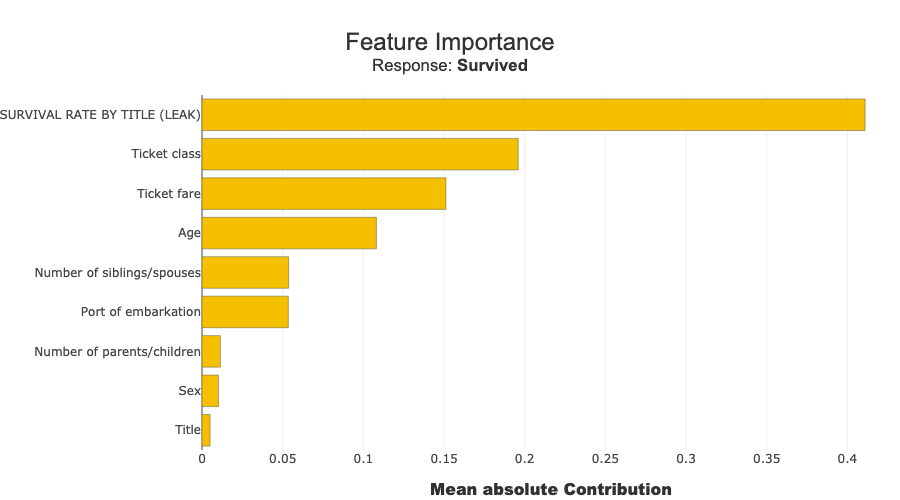

In [6]:
xpl_bug.plot.features_importance()

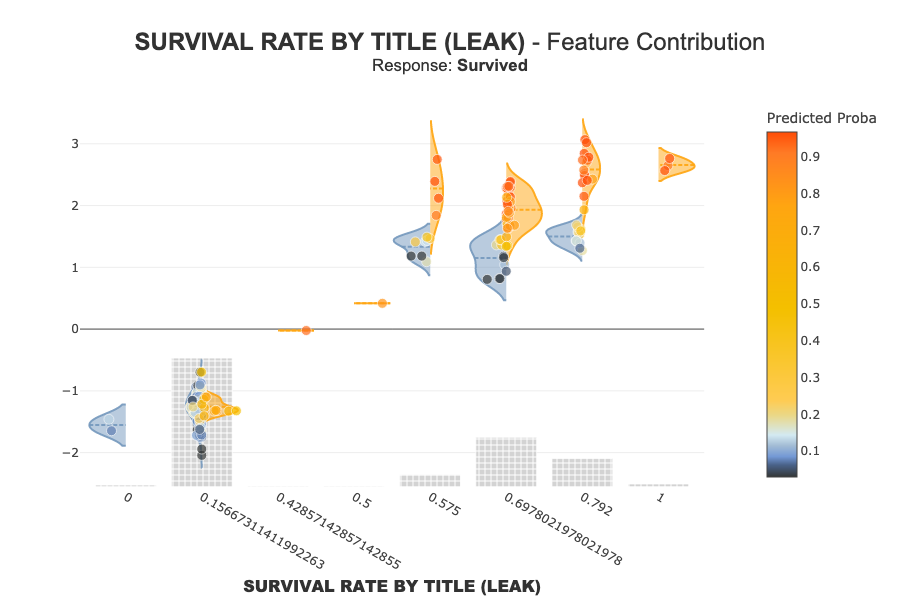

In [7]:
xpl_bug.plot.contribution_plot("leak_survival_rate_by_title")

If `SURVIVAL RATE BY TITLE (LEAK)` is a dominant feature, this is a red flag:
- this variable is not truly available in production
- it contains information derived from the target
- observed performance is overly optimistic

## 5. Fix the pipeline (without target leakage)

In [ ]:
features_clean = ["Pclass", "Age", "Sex", "SibSp", "Parch", "Fare", "Embarked", "Title"]

X_clean_raw = titanic_df[features_clean]
y_clean = titanic_df[[target_name]]

X_clean_train_raw, X_clean_test_raw, y_clean_train, y_clean_test = train_test_split(
    X_clean_raw,
    y_clean,
    test_size=0.25,
    random_state=42,
    stratify=y_clean,
)

encoder_clean = one_hot.OneHotEncoder(cols=["Sex", "Embarked", "Title"])
X_clean_train = encoder_clean.fit_transform(X_clean_train_raw)
X_clean_test = encoder_clean.transform(X_clean_test_raw)

model_clean = LGBMClassifier(max_depth=4, n_estimators=200, learning_rate=0.05, verbose=-1)
model_clean.fit(X_clean_train, y_clean_train.iloc[:, 0])

y_clean_pred_train = model_clean.predict(X_clean_train)
y_clean_pred_test = model_clean.predict(X_clean_test)

metrics_clean = pd.DataFrame(
    [
        cls_metrics(y_clean_train.iloc[:, 0], y_clean_pred_train),
        cls_metrics(y_clean_test.iloc[:, 0], y_clean_pred_test),
    ],
    index=["train_clean", "test_clean"],
)
metrics_clean

,accuracy,precision,recall,f1
train_clean,0.907186,0.925439,0.824219,0.871901
test_clean,0.798206,0.788732,0.651163,0.713376


INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x122d1b2c0>


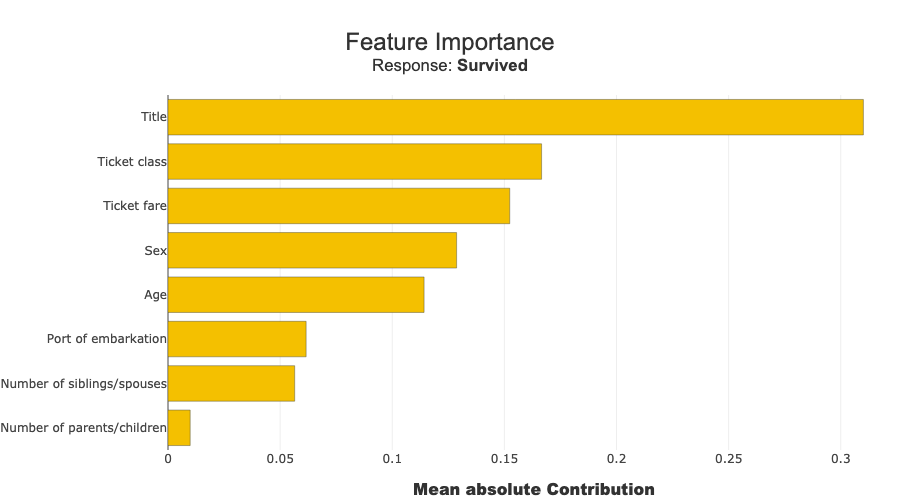

In [9]:
xpl_clean = SmartExplainer(
    model=model_clean,
    preprocessing=encoder_clean,
    features_dict={k: v for k, v in feature_dict_bug.items() if k in features_clean},
    label_dict={0: "Deceased", 1: "Survived"},
    postprocessing=postprocess,
    title_story="Titanic model debugging - cleaned version",
)

y_clean_pred_test_df = pd.DataFrame(
    model_clean.predict(X_clean_test),
    columns=[target_name],
    index=X_clean_test.index,
)

xpl_clean.compile(
    x=X_clean_test,
    y_pred=y_clean_pred_test_df,
    y_target=y_clean_test,
    additional_data=titanic_df.loc[X_clean_test.index, ["Name", "Title", "Fare", "Embarked"]],
)

xpl_clean.plot.features_importance()

In [10]:
comparison = pd.concat([metrics_bug, metrics_clean])
comparison

,accuracy,precision,recall,f1
train_bug,0.913174,0.930435,0.835938,0.880658
test_bug,0.802691,0.791667,0.662791,0.721519
train_clean,0.907186,0.925439,0.824219,0.871901
test_clean,0.798206,0.788732,0.651163,0.713376


## 6. Functional and numerical validation checklist

Apply this before production release:

Functional validation:
- are all features available at prediction time?
- are business rules stable over time?
- is the target definition consistent with the business objective?
- are edge business cases covered (rare profiles, extreme values)?

Data and numerical validation:
- missing values: rate, imputation strategy, impact on predictions
- outliers: plausible bounds, winsorization/capping if needed
- train vs production distribution: drift on critical features
- encoding: unknown categories, column order, expected numeric types
- metrics: track precision/recall/f1, not only accuracy

## 7. Launch the Shapash webapp (optional)

As in `shapash/webapp/webapp_launch.py`, initialize the app and retrieve the Dash object.

In [11]:
xpl_clean.init_app()
app = xpl_clean.smartapp.app
app
# Explicit launch: app.run_server(debug=False, host="0.0.0.0", port=8080)